## TD N°2 explicabilité du dataset Boston Housing

1) Charger le dataset bostong_housing
   1) Disponible dans le folder 04_interpretable_ml/td/data/
   
2) Nettoyer votre jeu de données pour créer une régression linéaire et un random forest
   1) Tester d'ajouter des features log, quadratique, ...

3)Créer un modèle baseline linéaire et random forest

4) Interpréter le modèle linéaire

5) Tuner votre random forest

6) Interpréter globalement votre modèle meilleur modèle RF 
   1) Utiliser les PDP ou ALE & Permutation feature Importance 
   2) Comparer les résulats du random forest avec votre interprétation du modèle linéaire

6) Réaliser une explicabilité par individu
   1) En utilisant la méthode ICE (PDP individuelle)
   2) LIME (Model local pour expliquer une prédiction)
   3) SHAP watterfall plot (Contribution marginale de chaque variable dans la prédiction)

7) Réaliser une explicabilité par individu sur le modèle RF
- 1) ICE, le PDP est-il une bonne représentation des variables importantes de votre modèle?
- 2) LIME
- 3) SHAP watterfall plot

8) Explorer les graphiques SHAP étudiés  dans la partie CM
   1) beeswarm (Contribution des variables)
   2) scatter (équivalent pdp)

## Contexte du Dataset

Le Boston Housing Dataset est un ensemble de données couramment utilisé en apprentissage automatique et en statistique pour étudier les relations entre diverses caractéristiques socio-économiques et immobilières dans la ville de Boston.  
Il contient des informations sur des propriétés résidentielles et leur environnement, et est souvent utilisé pour prédire la valeur des maisons, un problème classique de régression.

**Variable dispo**: 
- CRIM : taux de criminalité par habitant par ville
- ZN : proportion de terrains résidentiels zonés pour des lots de plus de 25 000 pieds carrés
- INDUS : proportion de terrains commerciaux non commerciaux par ville
- CHAS : variable binaire indiquant la proximité de la rivière Charles (= 1 si la zone délimitée par la ville touche la rivière ; 0 sinon)
- NOX : concentration des oxydes d'azote (en parties par 10 millions)
- RM : nombre moyen de pièces par logement
- AGE : proportion des unités occupées par leur propriétaire et construites avant 1940
- DIS : distances pondérées vers cinq centres d'emploi de Boston
- RAD : indice d'accessibilité aux autoroutes radiales
- TAX : taux d'imposition foncière par valeur totale pour chaque tranche de 10 000 dollars
- PTRATIO : ratio élèves-enseignants par ville
- LSTAT : pourcentage de la population de statut socio-économique inférieur
- MEDV : valeur médiane des maisons occupées par leur propriétaire (en milliers de dollars) - **variable cible**


predire au plus proche la valeur médiane des maisons: problématique : regression 
metrique functinon, learning curve 

In [4]:
#Web request
import requests
import io
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

### 1) Charger le dataset bostong_housing

In [5]:
#Télécharge directement depuis Github
url = "https://raw.githubusercontent.com/Roulitoo/cours_iae/master/04_INTERPRETABLE_ML/td/data/boston_housing.csv" 
download = requests.get(url).content

df = pd.read_csv(io.StringIO(download.decode('utf-8')), sep=';')

In [6]:
df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,5.33,36.2


In [7]:
list(df.columns)


['Unnamed: 0',
 'CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'LSTAT',
 'MEDV']

In [8]:
df.isna().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

In [9]:
del df['Unnamed: 0']

### 2)Nettoyer votre jeu de données pour créer une régression linéaire et un random forest

Penser à :

- Vérifier comment encoder vos variables qualitatives pour la modélisation 
- Analyser les distributions
- Analyser les outliers 
- Analyser les corrélations

>Tester d'ajouter des features log, quadratique, ...

### Nettoyage des données et encodage

# 2.1 Encodage des variables qualitatives 

In [10]:
# regarder le type 
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
LSTAT      float64
MEDV       float64
dtype: object

La variable CHAS étant binaire, elle est conservée telle quelle.
La variable RAD, représentant un indice discret d'accessibilité, peut être traitée soit comme une variable ordinale, soit comme une variable catégorielle. Pour la regressions linéaire les deux RAD ( numérique et en One-Hot) vont etre tester. 

In [11]:
df["RAD"].unique()

array([ 1,  2,  3,  5,  4,  8,  6,  7, 24], dtype=int64)

In [12]:
# Création de deux bases pour pouvoir comparer les résultats plus tard 
df_original = df.copy()  # RAD numérique
df_encoded = pd.get_dummies(df_original, columns=['RAD'], drop_first=True)  # RAD encodé en variables binaires

## 2.2 Analyse des distributions 

Pour compléter la partie nettoyage des données, il est important de regarder les distributions des données. Cela permet de regarder la forme des variables (gaussienne, asymétrique…), voir la présence de valeurs extrêmes et si des transformations (log, sqrt…) sont nécessaires

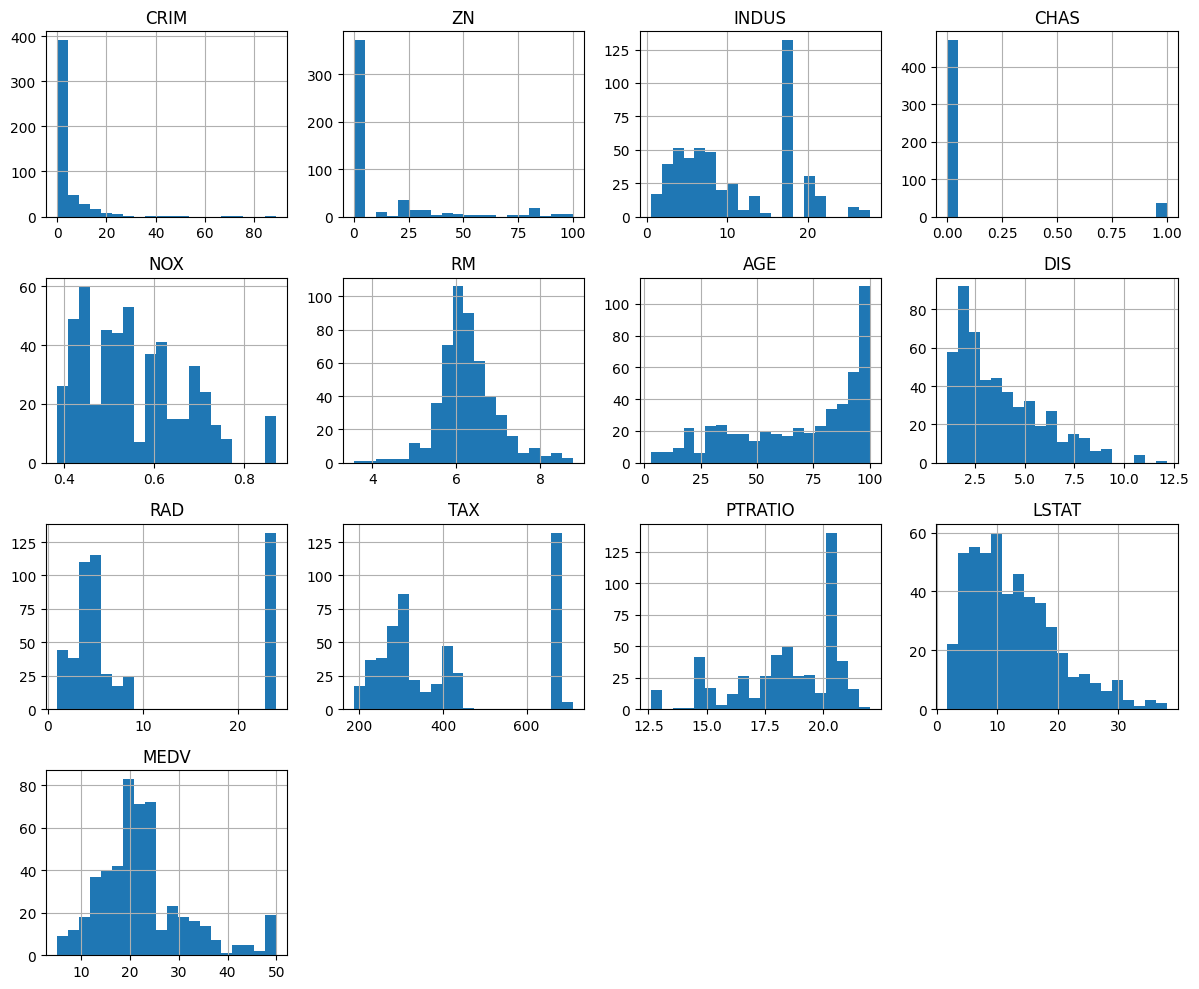

In [13]:
# analyse de la distribution 
import matplotlib.pyplot as plt

df_original.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

In [14]:
# on voit si il y a des variables asymétriques 
df_original.skew().sort_values(ascending=False)

CRIM       5.223149
CHAS       3.405904
ZN         2.225666
MEDV       1.108098
DIS        1.011781
RAD        1.004815
LSTAT      0.906460
NOX        0.729308
TAX        0.669956
RM         0.403612
INDUS      0.295022
AGE       -0.598963
PTRATIO   -0.802325
dtype: float64

L’analyse des distributions, à travers les histogrammes ainsi que le calcul du skewness, met en évidence que la majorité des variables ne suivent pas une distribution normale. Seule la variable RM semble se rapprocher d’une distribution symétrique de type gaussienne.

Plusieurs variables présentent une forte asymétrie positive. En particulier, CRIM possède un skewness très élevé (5.22), indiquant une distribution fortement étalée vers les grandes valeurs. De même, CHAS (3.40) et ZN (2.22) présentent également une asymétrie importante. Ces distributions traduisent la présence d’un grand nombre de valeurs faibles associées à quelques valeurs très élevées.

À l’inverse, certaines variables comme INDUS ou RM présentent un skewness plus proche de zéro, suggérant des distributions plus équilibrées.

Ces asymétries peuvent poser problème pour les modèles linéaires, qui reposent sur des hypothèses de linéarité et peuvent être sensibles aux distributions fortement déséquilibrées. Afin d’améliorer la qualité des données et de faciliter l’apprentissage, des transformations (notamment logarithmiques) seront appliquées aux variables les plus asymétriques. Ces transformations permettront de réduire l’effet des valeurs extrêmes, de rapprocher les distributions d’une forme plus symétrique et potentiellement d’améliorer les performances des modèles.

In [ ]:
# transformationS a faire : 
import numpy as np

df_original['CRIM_log'] = np.log1p(df_original['CRIM'])
df_original['ZN_log'] = np.log1p(df_original['ZN'])

df_encoded ['CRIM_log'] = np.log1p(df_encoded ['CRIM'])
df_encoded ['ZN_log'] = np.log1p(df_encoded ['ZN'])


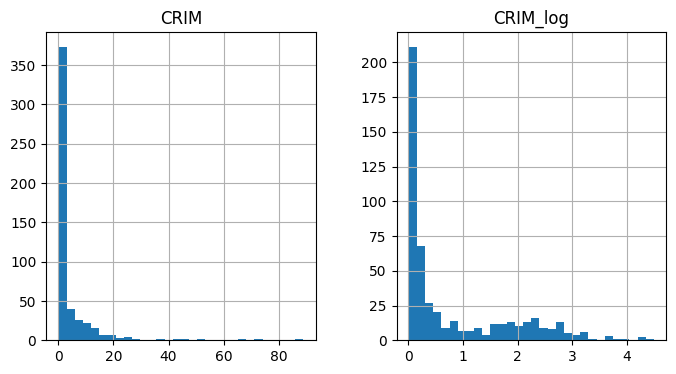

In [16]:
df_original[['CRIM', 'CRIM_log']].hist(bins=30, figsize=(8,4))
plt.show()

Il a été choisi de transformer uniquement les variables CRIM et ZN, car ce sont celles qui présentent les skewness les plus élevés, indiquant une forte asymétrie positive. Cette asymétrie traduit la présence d’un grand nombre de valeurs faibles et de quelques valeurs extrêmement élevées, susceptibles de perturber l’apprentissage des modèles linéaires.

Afin de corriger ce déséquilibre, une transformation logarithmique a été appliquée à ces variables. Le graphique ci-dessus illustre l’effet de cette transformation pour la variable CRIM. On observe que la distribution initiale est fortement concentrée sur les petites valeurs, avec une longue queue vers les grandes valeurs. Après transformation, la distribution devient plus étalée et plus symétrique, ce qui permet de réduire l’influence des valeurs extrêmes.

Cette transformation permet ainsi de rapprocher la distribution des variables d’une forme plus adaptée aux modèles linéaires, et peut contribuer à améliorer leurs performances. En revanche, les modèles non linéaires comme les Random Forest sont généralement moins sensibles à ce type de transformations.

## 2.3 Analyse des Outliers 

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'CRIM'),
  Text(1, 0, 'ZN'),
  Text(2, 0, 'INDUS'),
  Text(3, 0, 'CHAS'),
  Text(4, 0, 'NOX'),
  Text(5, 0, 'RM'),
  Text(6, 0, 'AGE'),
  Text(7, 0, 'DIS'),
  Text(8, 0, 'RAD'),
  Text(9, 0, 'TAX'),
  Text(10, 0, 'PTRATIO'),
  Text(11, 0, 'LSTAT'),
  Text(12, 0, 'MEDV'),
  Text(13, 0, 'CRIM_log'),
  Text(14, 0, 'ZN_log')])

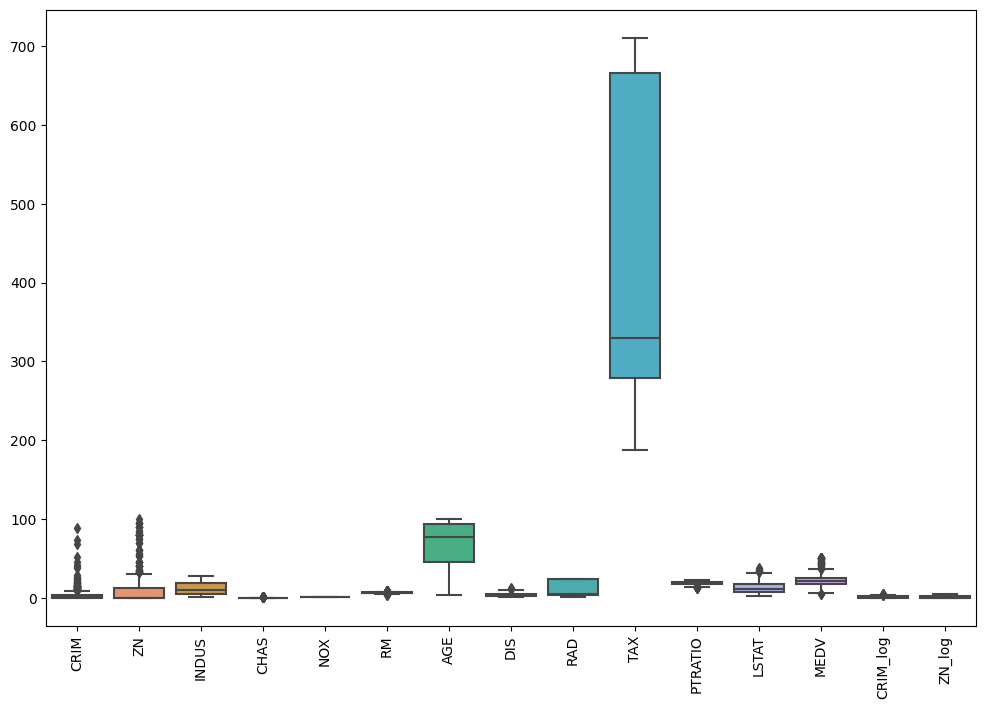

In [ ]:
# affichage des boxplots
plt.figure(figsize=(12,8))
sns.boxplot(data=df_original)
plt.xticks(rotation=90)

L’analyse des boxplots met en évidence la présence de nombreuses valeurs extrêmes dans certaines variables, notamment CRIM et ZN. Après application de la transformation logarithmique, on observe visuellement une réduction significative de l’amplitude des valeurs et du nombre d’outliers apparents. Cette transformation permet donc de limiter l’influence des valeurs extrêmes et de rendre les distributions plus homogènes.

Cependant, certaines variables telles que MEDV et LSTAT présentent encore des valeurs atypiques. Cela est cohérent avec les observations précédentes sur leur asymétrie, bien que le skewness ne soit pas le seul indicateur de la présence d’outliers. Ces valeurs extrêmes peuvent potentiellement influencer les modèles linéaires et devront donc être surveillées.

Afin d’approfondir cette analyse, nous allons maintenant quantifier de manière plus rigoureuse la présence d’outliers à l’aide de la méthode de l’IQR (Interquartile Range).

In [18]:
Q1 = df_original.quantile(0.25)
Q3 = df_original.quantile(0.75)
IQR = Q3 - Q1

outliers_count = ((df_original < (Q1 - 1.5 * IQR)) | 
                  (df_original > (Q3 + 1.5 * IQR))).sum()

outliers_count.sort_values(ascending=False)

ZN          68
CRIM        66
MEDV        40
CHAS        35
RM          30
PTRATIO     15
LSTAT        7
CRIM_log     6
DIS          5
INDUS        0
NOX          0
AGE          0
RAD          0
TAX          0
ZN_log       0
dtype: int64

Cette analyse  met en évidence la présence d’un nombre important de valeurs extrêmes pour certaines variables, notamment ZN, CRIM et MEDV. Cela est cohérent avec les observations précédentes sur l’asymétrie de ces variables.  

On observe également que les transformations logarithmiques appliquées à CRIM et ZN ont permis de réduire significativement le nombre d’outliers, confirmant leur utilité pour limiter l’influence des valeurs extrêmes.

Dans le cadre de cette étude, nous avons choisi de ne pas supprimer les outliers. En effet, ces valeurs extrêmes correspondent à des observations plausibles du jeu de données et peuvent contenir de l’information pertinente. De plus, la suppression d’un nombre important d’observations pourrait dégrader la qualité de l’apprentissage. Enfin, certains modèles comme les Random Forest sont naturellement robustes à la présence d’outliers.

## 2.4 Analyse des corrélations

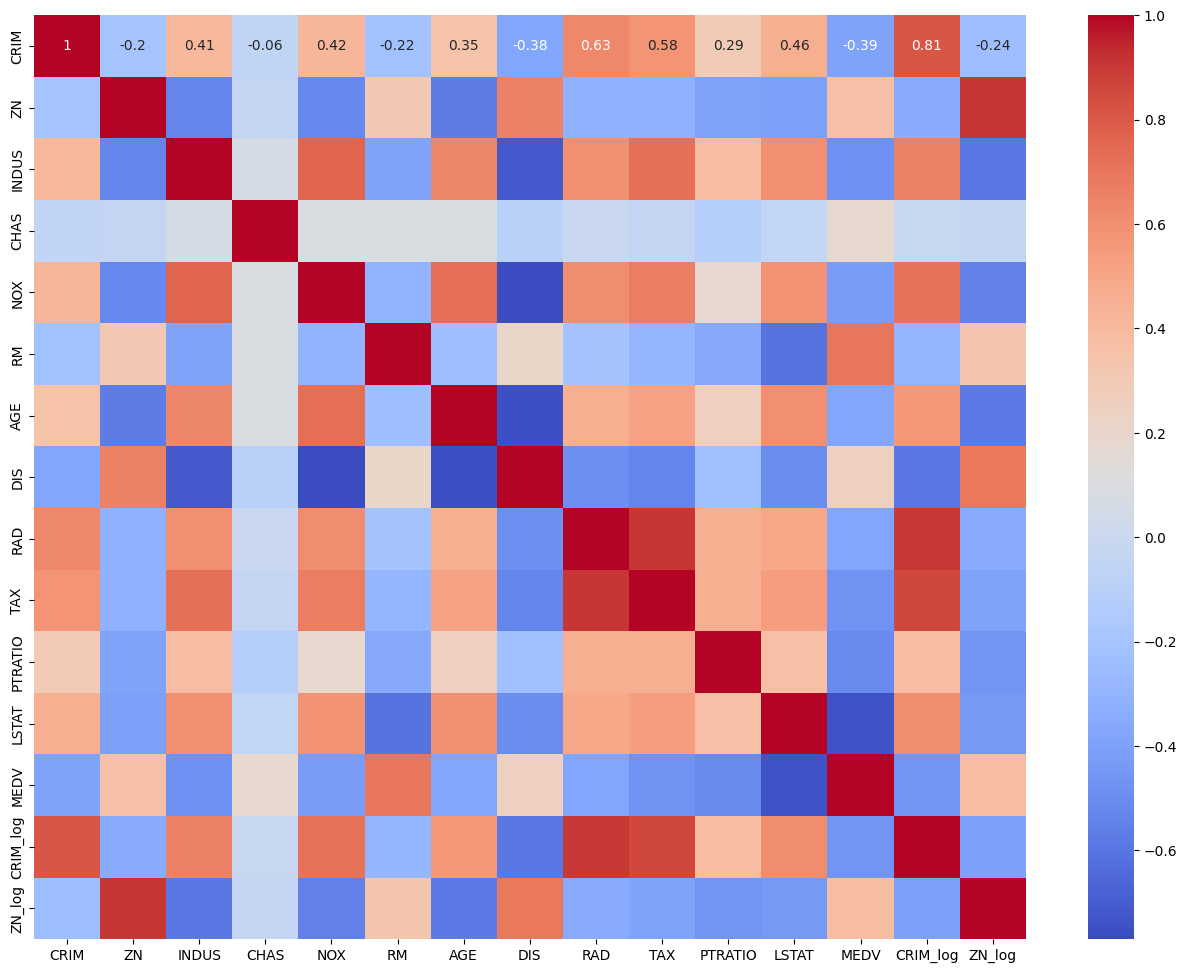

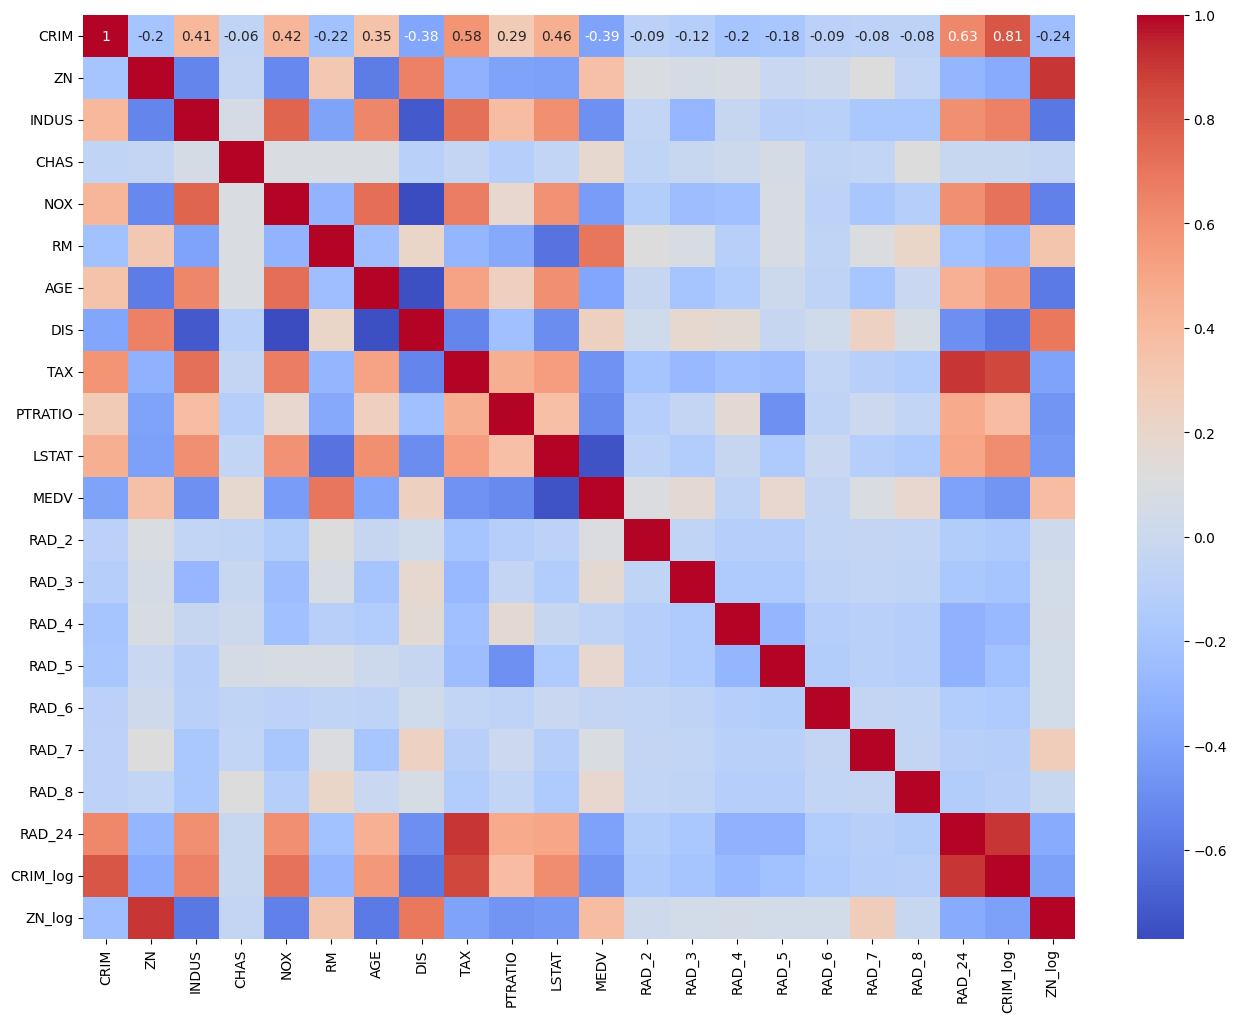

In [19]:
# analyse des corrélations entre les variables

plt.figure(figsize=(16,12))
correlation_matrix = df_original .corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

plt.figure(figsize=(16,12))
correlation_matrix = df_encoded.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

La matrice de corrélation permet d’identifier les relations linéaires fortes entre les variables explicatives. Des corrélations élevées entre variables peuvent poser problème dans l’analyse ultérieure, notamment en introduisant de la redondance d’information, en compliquant l’interprétation des résultats et, pour modèle linéaires en générant de la multicolinéarité.

On observe par exemple des corrélations importantes telles que : NOX et INDUS : 0,76, LSTAT et MEDV : -0,74...

Afin d’éviter une trop forte redondance entre variables,  un seuil de corrélation absolue de 0,70 a été fixé. Les variables dont la corrélation dépasse ce seuil seront examinées attentivement.

Toutefois, l’objectif n’est pas de supprimer systématiquement les deux variables corrélées, mais d’en conserver une seule, en privilégiant celle qui présente le plus d’intérêt explicatif ou économique. Une analyse détaillée des couples fortement corrélés est donc réalisée ci-dessous.

In [20]:

# Matrice de corrélation
corr_matrix =df_original.corr(numeric_only=True)

# Triangle supérieur (sans diagonale)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Liste des couples
strong_corr = upper.stack().reset_index()
strong_corr.columns = ['Variable_1', 'Variable_2', 'Correlation']

# Positives fortes
strong_corr_pos = strong_corr[strong_corr['Correlation'] > 0.7].sort_values('Correlation', ascending=False)

# Négatives fortes
strong_corr_neg = strong_corr[strong_corr['Correlation'] < -0.7].sort_values('Correlation', ascending=True)

strong_corr_pos, strong_corr_neg


(   Variable_1 Variable_2  Correlation
 84        RAD        TAX     0.910228
 26         ZN     ZN_log     0.906234
 88        RAD   CRIM_log     0.904753
 93        TAX   CRIM_log     0.860381
 12       CRIM   CRIM_log     0.810249
 28      INDUS        NOX     0.763651
 51        NOX        AGE     0.731470
 33      INDUS        TAX     0.720760
 58        NOX   CRIM_log     0.707587,
    Variable_1 Variable_2  Correlation
 52        NOX        DIS    -0.769230
 69        AGE        DIS    -0.747881
 99      LSTAT       MEDV    -0.737663
 31      INDUS        DIS    -0.708027)

L’analyse de la matrice de corrélation met en évidence plusieurs corrélations fortes entre certaines variables explicatives, notamment entre RAD, TAX et CRIM_log, ainsi qu’entre INDUS, NOX et AGE. Ces corrélations traduisent une redondance d’information qui peut poser problème pour les modèles linéaires, en particulier en introduisant des phénomènes de multicolinéarité, susceptibles de rendre l’estimation des coefficients instable et difficile à interpréter.

Afin de limiter cet effet tout en conservant un maximum d’information, il a été choisi de supprimer uniquement une variable au sein de chaque groupe fortement corrélé, plutôt que d’éliminer l’ensemble des variables concernées. L’objectif est ainsi de réduire la redondance tout en préservant la richesse explicative du jeu de données.

Dans cette optique, les variables RAD et TAX, fortement corrélées entre elles et avec CRIM_log, ont été supprimées. La variable CRIM_log a été conservée car elle capture directement le niveau de criminalité, information particulièrement pertinente pour l’analyse du prix des logements. De même, parmi le groupe INDUS, NOX et AGE, les variables INDUS et AGE ont été supprimées, tandis que NOX a été conservée car elle représente directement un indicateur de pollution de l’air, variable souvent associée à l’attractivité résidentielle.

Par ailleurs, certaines variables présentent une forte corrélation avec la variable cible, notamment LSTAT avec MEDV. Toutefois, ces variables ont été conservées car elles apportent une information essentielle pour la prédiction et ne posent pas de problème de multicolinéarité dans la mesure où leur corrélation concerne principalement la variable cible et non les autres variables explicatives.

Cette stratégie permet ainsi de réduire la multicolinéarité tout en conservant un ensemble de variables explicatives riche et interprétable, facilitant l’estimation et l’interprétation des modèles.

In [ ]:
# suppression des variables trop corrélés  : 
del df_original['RAD']
del df_original['TAX']
del df_original['INDUS']
del df_original['AGE']

# on supprime égalemen les variable non transformée
del df_original['CRIM']
del df_original['ZN']

In [22]:
# on fait la meme chose pour la base encodé :
del df_encoded['TAX']
del df_encoded['INDUS']
del df_encoded['AGE']
del df_encoded['CRIM']
del df_encoded['ZN']

# 3) Créer un modèle baseline linéaire et random forest

Étant donné les différences d’échelles importantes entre les variables (par exemple TAX,  NOX, etc), on va  appliquer une normalisation afin d’éviter qu’une variable domine l’apprentissage uniquement par sa magnitude. Cette étape est particulièrement importante pour les modèles basés sur les distances ou la régularisation, comme la régression linéaire  et les SVM . Nous utilisons ici une standardisation (moyenne nulle et variance unitaire) via StandardScaler. 

In [23]:
# préparation de x et y 

from sklearn.model_selection import train_test_split

target = "MEDV"

X = df_original.drop(columns=[target])
y = df_original[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# variante 2: avec df_encoded
X_encoded = df_encoded.drop(columns=[target])
y_encoded = df_encoded[target]
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)


In [24]:
# regression linéaire avec scalling dans un pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linreg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

# variante 2 : avec df_encoded
linreg_enc = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linreg_enc.fit(X_train_enc, y_train_enc)
y_pred_enc = linreg_enc.predict(X_test_enc)

La normalisation est appliquée uniquement à la régression linéaire, car ce modèle est sensible à l’échelle des variables. À l’inverse, la Random Forest repose sur des arbres de décision et n’exige pas de standardisation préalable.

In [63]:
# random forest sans scalling
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


# 4) Interpréter le modèle linéaire

In [56]:
import pandas as pd

# récupérer le modèle entraîné
model = linreg.named_steps['model']

# noms des variables
feature_names = X_train.columns

# coefficients
coeffs = model.coef_

# dataframe pour afficher proprement
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coeffs
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
coef_df

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)
coef_df


,Variable,Coefficient,Abs_Coefficient
5,LSTAT,-3.914294,3.914294
2,RM,3.151846,3.151846
3,DIS,-2.868094,2.868094
1,NOX,-2.044232,2.044232
4,PTRATIO,-1.884640,1.884640
0,CHAS,0.893422,0.893422
7,ZN_log,0.494816,0.494816
6,CRIM_log,-0.459326,0.459326


In [54]:
from sklearn.metrics import r2_score

y_pred = linreg.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R2 :", r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE :", rmse)

R2 : 0.6590571191258277
RMSE : 5.000263122684883


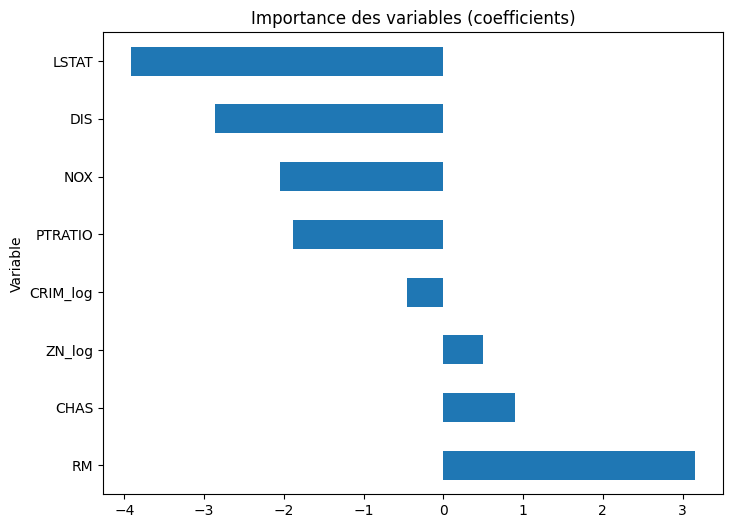

In [28]:
import matplotlib.pyplot as plt

coef_df.set_index("Variable")["Coefficient"].plot(kind="barh", figsize=(8,6))
plt.title("Importance des variables (coefficients)")
plt.show()

Le modèle obtient un coefficient de détermination (R2 = 0.659), ce qui signifie qu’environ 66 % de la variance du prix des logements est expliquée par les variables du modèle. Ce résultat indique que le modèle capture une part importante des relations présentes dans les données, bien qu’une partie de la variance reste inexpliquée.

L’analyse des coefficients montre que certaines variables ont une influence particulièrement forte. La variable RM (nombre moyen de pièces) présente le coefficient positif le plus élevé, ce qui indique qu’un logement comportant davantage de pièces a tendance à avoir une valeur plus élevée. De même, la variable CHAS, indiquant la proximité de la rivière Charles, est associée à une augmentation du prix des logements.

À l’inverse, certaines variables ont un impact négatif important. La variable LSTAT, représentant la proportion de population à faible statut socio-économique, présente l’effet négatif le plus marqué. Cela signifie qu’une augmentation de cette proportion est associée à une diminution significative de la valeur des logements. D’autres variables comme DIS (distance aux centres d’emploi), NOX (niveau de pollution) et PTRATIO (ratio élèves-enseignants) ont également un impact négatif sur les prix immobiliers.

In [55]:
# R2 de la variante encodé
y_pred_enc = linreg_enc.predict(X_test_enc)
r2_enc = r2_score(y_test_enc, y_pred_enc)
print("R2 (encodé) :", r2_enc)

rmse_enc = np.sqrt(mean_squared_error(y_test_enc, y_pred_enc))
print("RMSE (encodé) :", rmse_enc)


R2 (encodé) : 0.6650296950487407
RMSE (encodé) : 4.9562727637250665


Afin d’évaluer l’impact de l’encodage de la variable RAD, deux approches ont été testées. Dans un premier modèle, RAD a été supprimée du jeu de données en raison de sa forte corrélation avec d’autres variables explicatives. Dans un second modèle, la variable RAD a été conservée sous forme d’un encodage one-hot, permettant de représenter chaque valeur comme une catégorie indépendante.

Les résultats montrent une légère amélioration des performances avec le jeu de données encodé, le coefficient de détermination passant de (R^2 = 0.659) à (R^2 = 0.665), tout comme pour le RMSE passant de 5.00 à 4,95. Toutefois, cette amélioration reste très limitée et peut également s’expliquer par l’augmentation du nombre de variables introduites par l’encodage one-hot.

Afin de conserver un modèle plus simple et de limiter les problèmes potentiels de redondance entre variables, la suite de l’analyse sera réalisée à partir du jeu de données initial ne contenant pas la variable RAD.

# 5) Tuner votre random forest

Afin de garantir les meilleurs performances du modèle en foret aléatoire, il est préférable d'optimiser les hyperparamètres. C'est pourquoi nous allons  utiliser une validation croisée pour trouver les meilleurs paramètres (GridSearch)

Les principaux hyperparamètres étudiés sont le nombre d’arbres (n_estimators), la profondeur maximale des arbres (max_depth), le nombre minimum d’échantillons nécessaires pour créer une division (min_samples_split) ainsi que le nombre minimum d’échantillons dans une feuille (min_samples_leaf). Le paramètre max_features a également été testé afin de contrôler le nombre de variables utilisées lors de la construction des arbres.

La recherche des meilleurs paramètres a été réalisée à l’aide d’une validation croisée à cinq folds en optimisant le coefficient de détermination (R2). Le modèle final correspond à la combinaison d’hyperparamètres obtenant les meilleures performances sur les données d’entraînement.

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# meilleurs paramaètres 
print("Best parameters:", grid_search.best_params_)

#meilleur modèle
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [31]:
# evaluation du modèle optimisé
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("R2 Random Forest :", r2_rf)
print("RMSE Random Forest :", rmse_rf)

R2 Random Forest : 0.8653876912050804
RMSE Random Forest : 3.141914999467215


In [66]:
print("Meilleur score CV :", grid_search.best_score_)

Meilleur score CV : 0.8411467632790484


Après optimisation des hyperparamètres , le modèle Random Forest obtient les paramètres suivants : une profondeur maximale des arbres de 20 (max_depth = 20), l’utilisation de la racine carrée du nombre de variables pour chaque division (max_features = sqrt), un minimum d’un échantillon par feuille (min_samples_leaf = 1), deux échantillons minimum pour effectuer une division (min_samples_split = 2) et 200 arbres dans la forêt (n_estimators = 200).

Avec ces paramètres optimisés, le modèle atteint un coefficient de détermination (R2 = 0.865) sur l’ensemble de test, ce qui signifie qu’environ 86 % de la variance de la variable cible est expliquée par le modèle. Le RMSE obtenu est de 3.14, indiquant que l’erreur moyenne de prédiction se situe autour de 3.1 unités sur l’échelle de la variable MEDV.

Ces résultats montrent une amélioration notable par rapport au modèle de régression linéaire précédemment étudié. Cela suggère que certaines relations entre les variables explicatives et la variable cible peuvent être non linéaires et mieux capturées par un modèle basé sur des arbres.

Toutefois, ces résultats ne permettent pas encore de comprendre précisément le rôle de chaque variable dans les prédictions. Une analyse d’interprétabilité globale du modèle sera donc réalisée dans la suite à l’aide de méthodes telles que la Permutation Feature Importance et les Partial Dependence Plots.

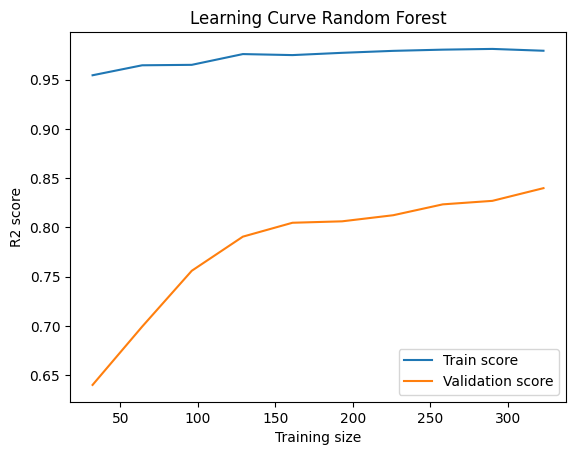

In [67]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_train, y_train, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train score")
plt.plot(train_sizes, test_mean, label="Validation score")
plt.xlabel("Training size")
plt.ylabel("R2 score")
plt.title("Learning Curve Random Forest")
plt.legend()
plt.show()

Pour finir,  la learning curve du modèle Random Forest a été tracé  afin d’analyser l’évolution de ses performances en fonction de la taille de l’échantillon d’entraînement. On observe que le score sur l’ensemble d’entraînement reste élevé et relativement stable, tandis que le score de validation augmente progressivement à mesure que la taille de l’échantillon augmente. L’écart entre les deux courbes diminue légèrement mais reste présent, ce qui suggère que le modèle capture bien la structure des données tout en conservant une capacité de généralisation correcte. Globalement, ces résultats indiquent que l’ajout de données supplémentaires pourrait encore améliorer les performances du modèle, bien que celles-ci semblent déjà se stabiliser.

# 6) Interpréter globalement votre modèle meilleur modèle RF
1. Utiliser les PDP ou ALE & Permutation feature Importance
2. Comparer les résulats du random forest avec votre interprétation du modèle linéaire

### 6.1 Permutation Feature Importance (global)
La permutation feature importance permet d’estimer l’importance globale des variables en mesurant la diminution de performance (R²) lorsque les valeurs d’une variable sont permutées aléatoirement. Les variables dont la permutation entraîne la plus forte baisse de R² sont les plus influentes pour le modèle Random Forest. Cette mesure étant indépendante des coefficients, elle est particulièrement adaptée aux modèles non linéaires et permet une comparaison directe avec l’interprétation du modèle linéaire.


   Variable  Importance_mean  Importance_std
5     LSTAT         0.397353        0.064364
2        RM         0.296972        0.025665
1       NOX         0.076336        0.014686
3       DIS         0.065292        0.008486
4   PTRATIO         0.056582        0.010983
6  CRIM_log         0.042211        0.006307
7    ZN_log         0.001535        0.002534
0      CHAS        -0.001110        0.006885


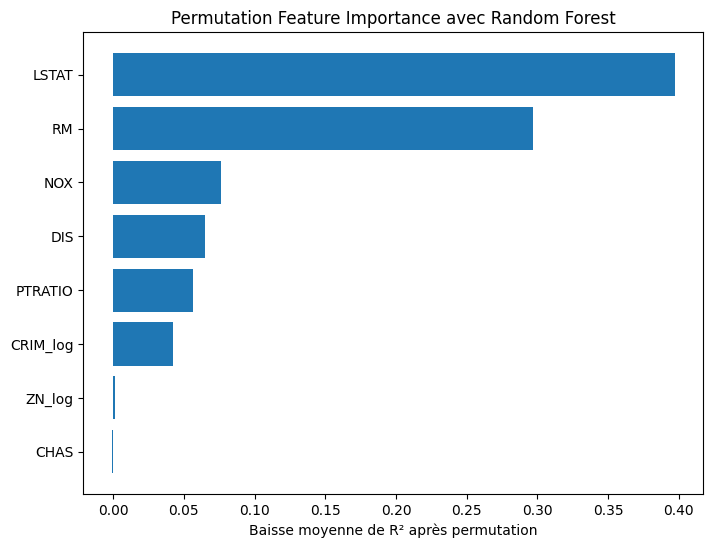

In [32]:
#6.1 Permutation Feature Importance (global)

from sklearn.inspection import permutation_importance


perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2"
)

imp_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance_mean": perm.importances_mean,
    "Importance_std": perm.importances_std
}).sort_values("Importance_mean", ascending=False)

print(imp_df.head(10))


top = imp_df.head(10).sort_values("Importance_mean")
plt.figure(figsize=(8,6))
plt.barh(top["Variable"], top["Importance_mean"])
plt.title("Permutation Feature Importance avec Random Forest")
plt.xlabel("Baisse moyenne de R² après permutation")
plt.show()

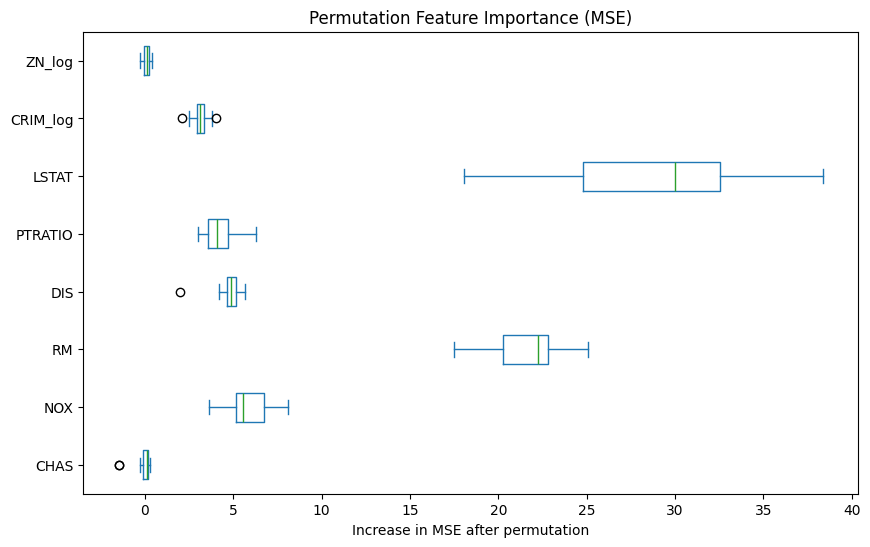

In [61]:
result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_squared_error"
)

importances = pd.DataFrame(
    result.importances.T,
    columns=X_test.columns
)

importances.plot.box(vert=False, figsize=(10,6))
plt.title("Permutation Feature Importance (MSE)")
plt.xlabel("Increase in MSE after permutation")
plt.show()

Les résultats montrent que la variable LSTAT est de loin la plus importante pour le modèle Random Forest. La permutation de cette variable entraîne une baisse moyenne du (R^2) d’environ 0.40, ce qui indique qu’elle joue un rôle majeur dans la prédiction du prix des logements. Cette variable représente la proportion de population à faible statut socio-économique et semble donc fortement liée à la valeur des biens immobiliers.

La deuxième variable la plus influente est RM, correspondant au nombre moyen de pièces par logement. Sa permutation entraîne une diminution importante des performances (environ 0.30), ce qui confirme que la taille des logements constitue un facteur déterminant dans l’estimation de leur valeur.

Les variables NOX, DIS et PTRATIO présentent également une influence notable, bien que plus modérée. Elles reflètent respectivement le niveau de pollution, la distance aux centres d’emploi et le ratio élèves-enseignants, ce qui suggère que les caractéristiques environnementales et socio-économiques jouent également un rôle dans la détermination du prix des logements.

À l’inverse, les variables ZN_log et CHAS présentent une importance très faible, voire nulle dans le cas de CHAS. Cela indique que leur contribution aux prédictions du modèle Random Forest est limitée dans ce contexte.



### 6.2 Partial Dependence Plot (PDP)
Les Partial Dependence Plots (PDP) illustrent l’effet moyen d’une variable sur la prédiction du prix, en marginalisant les autres variables. Ils permettent de visualiser des relations non linéaires capturées par le Random Forest. Une relation fortement courbée, présentant des paliers ou des effets seuils, indique que l’influence de la variable n’est pas constante et ne peut pas être correctement représentée par un modèle strictement linéaire.

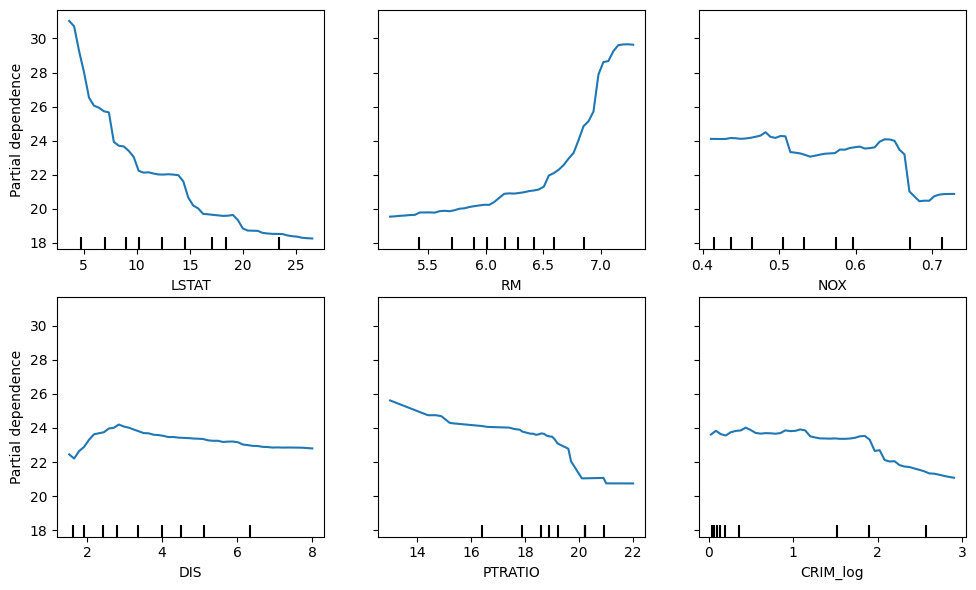

In [60]:
from sklearn.inspection import PartialDependenceDisplay

top_features = imp_df["Variable"].head(6).tolist()  

fig, ax = plt.subplots(figsize=(10,6))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=top_features,
    kind="average",
    grid_resolution=50,
    ax=ax
)
plt.tight_layout()
plt.show()

La variable LSTAT présente une relation clairement décroissante avec la valeur prédite des logements. Lorsque la proportion de population à faible statut socio-économique augmente, le prix prédit des logements diminue fortement. Cette tendance est particulièrement marquée pour les faibles valeurs de LSTAT, puis la décroissance devient plus progressive pour les valeurs plus élevées.

La variable RM, correspondant au nombre moyen de pièces par logement, montre une relation positive avec la valeur prédite. Plus le nombre de pièces augmente, plus la valeur estimée des logements augmente également. On observe notamment une augmentation plus prononcée pour les valeurs élevées de RM.

Pour la variable NOX, représentant la concentration de pollution, la relation observée est globalement négative. Une augmentation du niveau de pollution est associée à une diminution du prix des logements. Toutefois, la relation n’est pas parfaitement linéaire et présente certaines variations selon les niveaux de pollution.

La variable DIS, qui mesure la distance aux centres d’emploi, présente un effet plus modéré. On observe une légère augmentation de la valeur des logements pour des distances intermédiaires, suivie d’une stabilisation pour les valeurs plus élevées.

La variable PTRATIO montre une relation globalement négative : lorsque le ratio élèves-enseignants augmente, la valeur prédite des logements tend à diminuer. Cela peut refléter l’impact de la qualité perçue du système éducatif sur l’attractivité d’une zone résidentielle.

Pour la variable CRIM_log, correspondant au taux de criminalité transformé en logarithme, on observe également une tendance négative. Une augmentation du niveau de criminalité est associée à une diminution de la valeur des logements.

Les variables ZN_log et CHAS présentent quant à elles un effet relativement faible sur les prédictions du modèle. Leurs PDP montrent des variations limitées de la valeur prédite, ce qui suggère que leur influence sur la prédiction globale du modèle est relativement faible.

Dans l’ensemble, ces graphiques montrent que le modèle Random Forest capture des relations parfois non linéaires entre les variables explicatives et la variable cible, ce qui peut expliquer ses meilleures performances par rapport au modèle de régression linéaire.

PDP bivarié

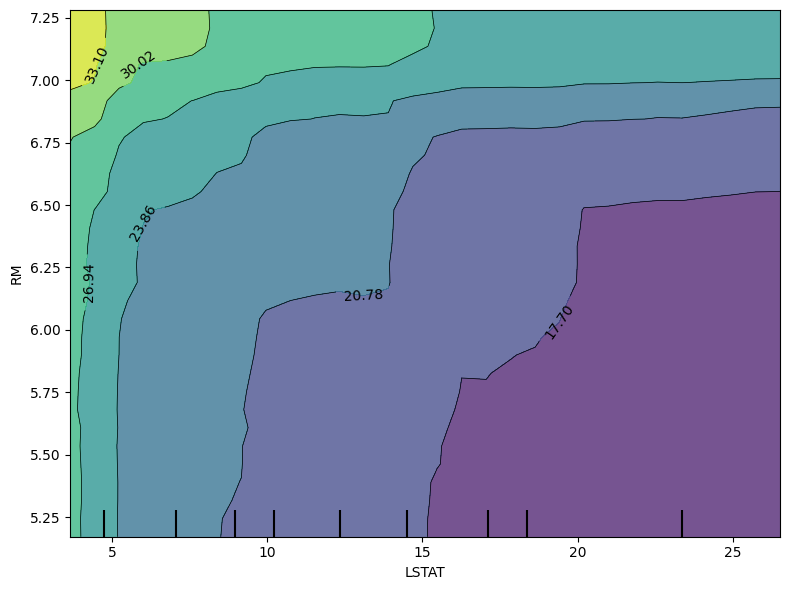

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[("LSTAT", "RM")],
    kind="average",
    grid_resolution=30,
    ax=ax
)
plt.tight_layout()
plt.show()

Afin de compléter l’analyse des PDP univariés, un PDP bivarié a été réalisé pour les variables LSTAT et RM, car elles ont été identifiées comme les variables les plus importantes dans les analyses précédentes. Ce type de graphique permet d’explorer l’effet combiné de deux variables sur la prédiction du modèle et d’identifier d’éventuelles interactions.

Le graphique montre que les valeurs les plus élevées de prédiction sont obtenues lorsque RM est élevé (grand nombre de pièces) et LSTAT est faible (faible proportion de population à statut socio-économique défavorisé). À l’inverse, lorsque LSTAT augmente et que RM diminue, la valeur prédite des logements diminue nettement.

Ces résultats suggèrent que le prix des logements dépend fortement de la combinaison de ces deux variables : les logements avec davantage de pièces situés dans des zones socio-économiquement favorisées ont tendance à avoir les valeurs les plus élevées.

### 6.2 bis Accumulated Local Effects (ALE)

c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M2\SV

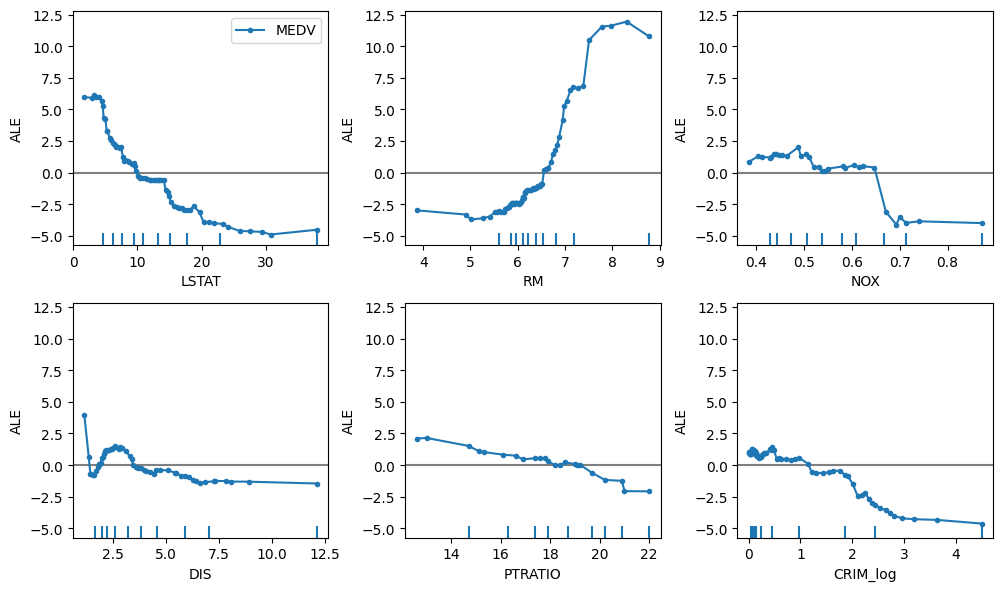

In [58]:
from alibi.explainers import ALE, plot_ale

feature_names = X_train.columns.tolist()

ale_explainer = ALE(
    best_rf.predict,
    feature_names=feature_names,
    target_names=["MEDV"]
)

ale_exp = ale_explainer.explain(X_train.to_numpy())

fig, ax = plt.subplots(figsize=(10, 6))
plot_ale(
    ale_exp,
    features=["LSTAT", "RM", "NOX", "DIS", "PTRATIO", "CRIM_log"],
    targets=[0],
    ax=ax
)
plt.show()


Les Accumulated Local Effects (ALE) permettent d’analyser l’influence moyenne d’une variable sur la prédiction du modèle tout en tenant compte de la distribution réelle des données. Contrairement aux Partial Dependence Plots, les ALE limitent l’effet des corrélations entre variables et fournissent ainsi une estimation plus locale de l’impact des variables explicatives.

Pour la variable LSTAT, on observe une relation clairement décroissante : lorsque la proportion de population à faible statut socio-économique augmente, la contribution de cette variable à la prédiction du modèle diminue fortement. Cette tendance suggère que des valeurs élevées de LSTAT sont associées à des prix de logements plus faibles.

À l’inverse, la variable RM montre une relation croissante avec la prédiction. Les valeurs plus élevées de RM, correspondant à un nombre plus important de pièces par logement, entraînent une augmentation notable de la valeur prédite.

Concernant NOX, la relation apparaît globalement négative. Lorsque le niveau de pollution augmente, la contribution de la variable devient progressivement négative, indiquant une diminution de la valeur prédite des logements.

La variable DIS présente un effet plus modéré et légèrement non linéaire. On observe une légère augmentation de la contribution pour certaines valeurs intermédiaires, suivie d’une stabilisation ou d’une diminution pour des distances plus élevées.

Pour PTRATIO, la relation observée est globalement décroissante : un ratio élèves-enseignants plus élevé est associé à une contribution plus négative à la prédiction du modèle.

Enfin, la variable CRIM_log présente également un effet négatif marqué : lorsque le niveau de criminalité augmente, la contribution de la variable devient de plus en plus négative, ce qui suggère une diminution du prix des logements.
Les tendances observées dans les ALE sont globalement similaires à celles des PDP, confirmant les effets principaux des variables tout en offrant une estimation plus robuste en présence de corrélations entre variables.

### 6.3 Comparaison Random Forest et modèle linéaire

In [64]:
results = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Régression linéaire encodée",
        "Random Forest baseline",
        "Random Forest tunée"
    ],
    "R2": [
        r2,
        r2_enc,
        r2_score(y_test, rf.predict(X_test)),
        r2_rf
    ],
    "RMSE": [
        rmse,
        rmse_enc,
        np.sqrt(mean_squared_error(y_test, rf.predict(X_test))),
        rmse_rf
    ]
})

results.sort_values("R2", ascending=False)

,Modèle,R2,RMSE
2,Random Forest baseline,0.874419,3.034687
3,Random Forest tunée,0.865388,3.141915
1,Régression linéaire encodée,0.665030,4.956273
0,Régression linéaire,0.659057,5.000263


La comparaison entre le modèle de régression linéaire et le modèle Random Forest montre des résultats globalement cohérents. Dans les deux cas, les variables LSTAT et RM apparaissent comme les plus influentes dans la prédiction du prix des logements. La variable LSTAT présente un effet négatif important, indiquant qu’une augmentation de la proportion de population à faible statut socio-économique est associée à une diminution du prix des logements. À l’inverse, la variable RM montre un effet positif, suggérant que les logements comportant davantage de pièces ont tendance à avoir une valeur plus élevée.

Les variables NOX, DIS, PTRATIO et CRIM_log présentent également des effets similaires dans les deux modèles, avec une influence généralement négative sur la valeur des logements. Les résultats obtenus avec la permutation feature importance et les Partial Dependence Plots confirment l’importance de ces variables dans le modèle Random Forest.

La principale différence entre les deux approches réside dans la forme des relations observées. La régression linéaire suppose une relation linéaire constante entre les variables explicatives et la variable cible, tandis que le Random Forest permet de capturer des relations plus complexes et non linéaires. Les Partial Dependence Plots montrent notamment que certaines relations ne sont pas strictement linéaires et peuvent présenter des effets de seuil.

En termes de performance prédictive, le Random Forest obtient des résultats nettement meilleurs que la régression linéaire, avec un RMSE plus faible et un R² plus élevé, ce qui est cohérent avec sa capacité à modéliser des interactions et des effets non linéaires entre les variables. Le modèle Random Forest optimisé présente toutefois des performances légèrement inférieures au modèle baseline sur l’échantillon test. Cette différence peut s’expliquer par le fait que l’optimisation des hyperparamètres est réalisée par validation croisée sur l’échantillon d’entraînement et ne garantit pas nécessairement une amélioration sur un jeu de test distinct.

## 7) Réaliser une explicabilité par individu sur le modèle RF
- 1) ICE, le PDP est-il une bonne représentation des variables importantes de votre modèle?
- 2) LIME
- 3) SHAP watterfall plot


### 7.1 ICE (Individual Conditional Expectation)
Les ICE plots montrent comment la prédiction du modèle change pour un individu spécifique lorsque l’on fait varier une variable. Ci dessous, une visualisation graphique des deux variables les plus importantes du modèle: 

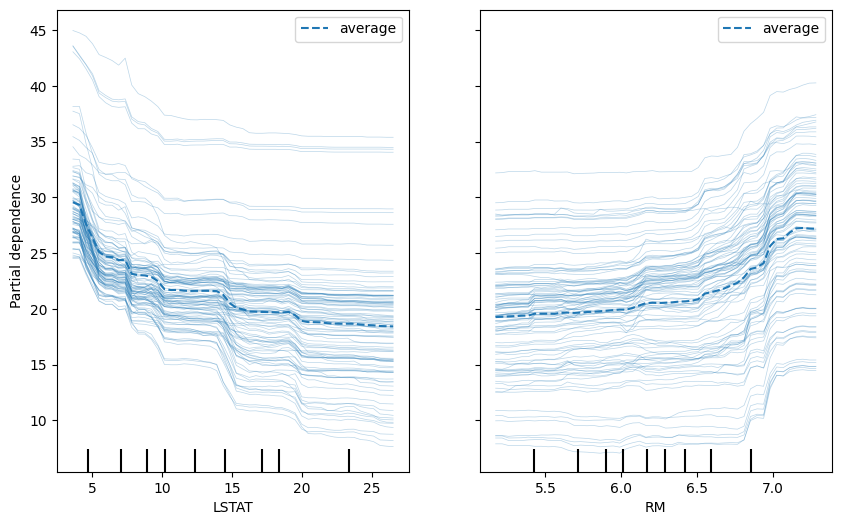

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

features = ["LSTAT", "RM"]

fig, ax = plt.subplots(figsize=(10,6))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=features,
    kind="both",  # PDP + ICE
    grid_resolution=50,
    ax=ax
)

plt.show()

Pour la variable LSTAT, on observe que la majorité des courbes individuelles suivent une tendance décroissante, lorsque la proportion de population à faible statut socio-économique augmente, la valeur prédite des logements diminue. Les courbes sont relativement parallèles, ce qui indique que l’effet négatif de LSTAT est globalement cohérent pour la plupart des observations. Cela confirme que le PDP précédemment observé constitue une bonne approximation de l’effet moyen de cette variable.

Concernant la variable RM, les courbes individuelles montrent majoritairement une tendance croissante : plus le nombre moyen de pièces augmente, plus la valeur prédite des logements augmente. On observe toutefois une dispersion plus importante entre certaines courbes, ce qui suggère que l’impact de RM peut varier légèrement selon les caractéristiques des observations.

Dans l’ensemble, les ICE plots confirment les tendances observées dans les PDP : LSTAT exerce un effet négatif marqué tandis que RM exerce un effet positif sur la prédiction du modèle. Les variations entre certaines courbes individuelles indiquent néanmoins que l’influence de ces variables peut dépendre du contexte des autres caractéristiques présentes dans les données.

### 7.2 LIME
L objectif du LIME est d'expliquer une prédiction locale en approximant le modèle complexe par un modèle linéaire simple autour de l’observation étudiée. On peut le voir ci-dessous. 

c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


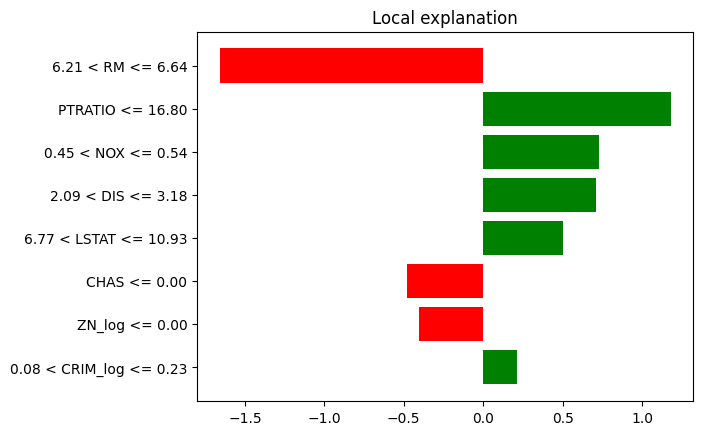

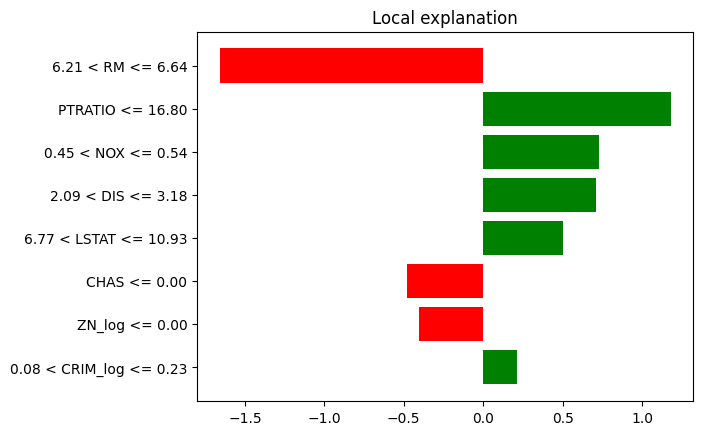

In [39]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode="regression"
)

i = 0  # individu à expliquer

exp = explainer.explain_instance(
    X_test.iloc[i].values,
    best_rf.predict,
    num_features=8
)

exp.as_pyplot_figure()

La méthode LIME permet d’expliquer localement la prédiction du modèle pour une observation spécifique en approximant le comportement du modèle par un modèle linéaire interprétable dans le voisinage de cette observation.

Dans le cas de l’individu étudié, certaines variables contribuent positivement à la prédiction tandis que d’autres ont un effet négatif. Les variables PTRATIO, NOX, DIS et LSTAT apparaissent comme les principaux facteurs augmentant la valeur prédite par le modèle. À l’inverse, La variable RM contribue négativement à la prédiction pour cet individu. Cette contribution ne signifie pas nécessairement que la valeur de RM est particulièrement faible dans l’ensemble du jeu de données, mais plutôt que, dans le voisinage de cette observation et compte tenu de la combinaison des autres variables, une valeur de RM dans cet intervalle est associée à une diminution de la valeur prédite par le modèle. Cela illustre le caractère local de l’explication fournie par LIME.

D’autres variables comme CHAS et ZN_log présentent également une contribution négative mais d’ampleur plus limitée, tandis que CRIM_log exerce une influence positive relativement faible.

Cette analyse montre que l’influence des variables peut varier selon l’individu considéré. Contrairement aux méthodes globales comme les PDP ou la permutation importance, LIME permet de comprendre les facteurs spécifiques qui expliquent la prédiction du modèle pour une observation donnée.

Après une première interprétation locale avec LIME, on mobilise également SHAP, méthode plus cohérente théoriquement, afin d’analyser à la fois l’explication locale d’un individu et la structure globale des contributions des variables.

### 7.3 SHAP Waterfall Plot

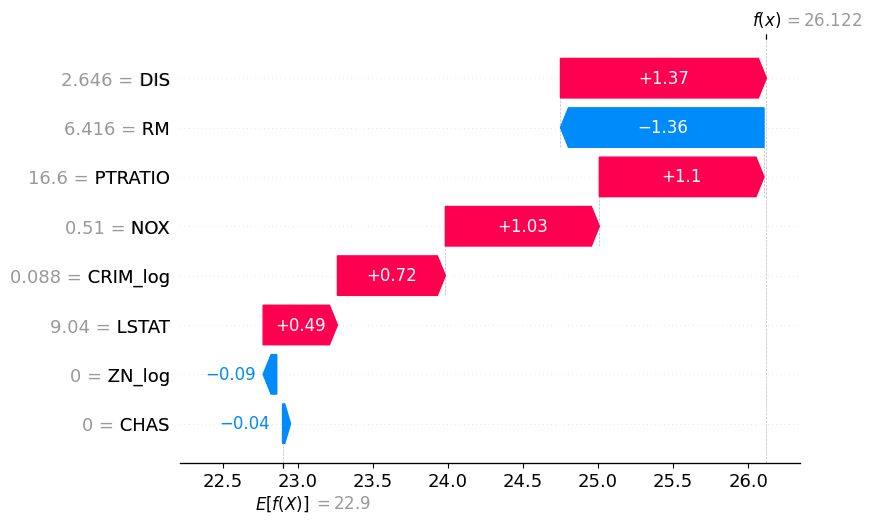

In [44]:
import shap


explainer = shap.TreeExplainer(best_rf)

shap_values = explainer(X_test)


i = 0  # individu choisi

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns
    )
)

Le graphique SHAP de type waterfall permet d’expliquer la prédiction du modèle pour une observation donnée en montrant la contribution de chaque variable à la prédiction finale. Le point de départ correspond à la valeur moyenne des prédictions du modèle, notée (E[f(X)]), qui est ici d’environ 22.9. Chaque variable contribue ensuite positivement ou négativement à cette valeur moyenne pour aboutir à la prédiction finale du modèle, qui est ici (f(x) = 26.12).

Pour l’individu étudié, plusieurs variables contribuent à augmenter la prédiction. Les contributions positives les plus importantes proviennent des variables DIS, PTRATIO et NOX, qui augmentent respectivement la prédiction d’environ +1.37, +1.10 et +1.03. Les variables CRIM_log et LSTAT apportent également une contribution positive mais plus modérée.

À l’inverse, certaines variables réduisent la valeur prédite. La variable RM exerce la contribution négative la plus importante (-1.36), tandis que ZN_log et CHAS ont un effet négatif beaucoup plus faible.

Contrairement aux méthodes globales, les valeurs SHAP permettent de comprendre précisément quels facteurs influencent la prédiction pour une observation particulière, tout en restant cohérentes avec les tendances globales observées précédemment.

## 8) Explorer les graphiques SHAP étudiés dans la partie CM
1. beeswarm (Contribution des variables)


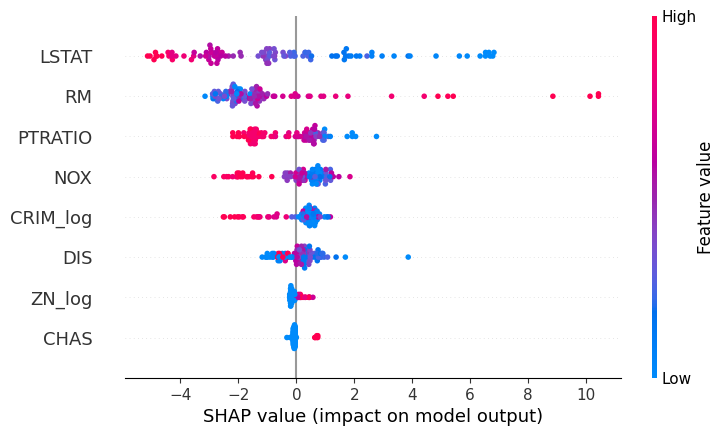

In [43]:
shap.plots.beeswarm(shap_values)

Le graphique SHAP beeswarm permet de visualiser l’importance globale des variables ainsi que la direction de leur influence sur les prédictions du modèle. Chaque point représente une observation, tandis que la position sur l’axe horizontal indique la contribution de la variable à la prédiction. La couleur représente la valeur de la variable pour l’observation correspondante.

On observe que les variables LSTAT et RM sont les plus influentes dans le modèle, car elles présentent la plus grande dispersion des valeurs SHAP. Cela confirme les résultats obtenus précédemment avec la permutation feature importance et les PDP.

Pour la variable LSTAT, les valeurs élevées (en rouge) sont associées à des contributions négatives importantes sur la prédiction du modèle, tandis que les valeurs faibles (en bleu) tendent à augmenter la prédiction. Cela signifie qu’une proportion élevée de population à faible statut socio-économique est associée à une diminution du prix des logements.

À l’inverse, la variable RM présente un effet positif : les valeurs élevées (en rouge) entraînent des contributions positives importantes, ce qui indique que les logements comportant davantage de pièces sont associés à des valeurs plus élevées.

Les variables PTRATIO, NOX, CRIM_log et DIS présentent également une influence sur les prédictions du modèle, mais avec une amplitude plus faible. Leurs contributions indiquent globalement qu’une augmentation de ces variables tend à réduire la valeur prédite des logements.

Enfin, les variables ZN_log et CHAS ont un impact très limité sur les prédictions, ce qui confirme les résultats observés dans les analyses précédentes.

2. scatter (équivalent pdp)

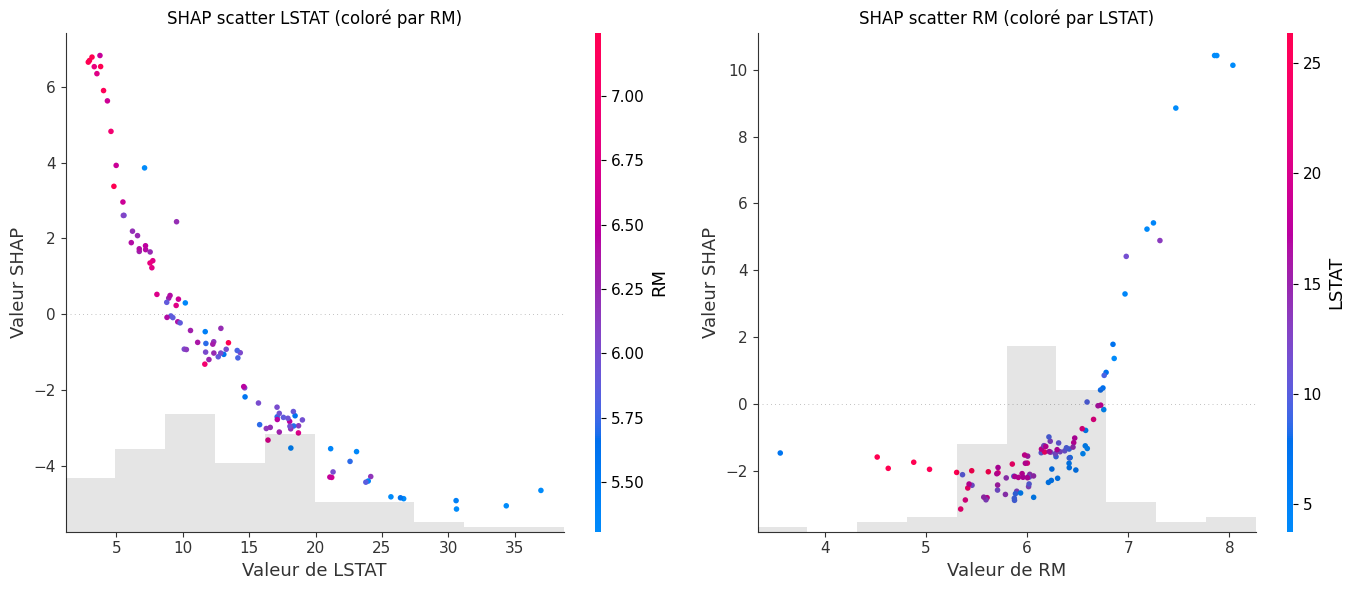

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SHAP scatter pour LSTAT, coloré par RM
shap.plots.scatter(
    shap_values[:, "LSTAT"],
    color=shap_values[:, "RM"],
    show=False,
    ax=axes[0]
)
axes[0].set_title("SHAP scatter LSTAT (coloré par RM)")
axes[0].set_xlabel("Valeur de LSTAT")
axes[0].set_ylabel("Valeur SHAP")

# SHAP scatter pour RM, coloré par LSTAT
shap.plots.scatter(
    shap_values[:, "RM"],
    color=shap_values[:, "LSTAT"],
    show=False,
    ax=axes[1]
)
axes[1].set_title("SHAP scatter RM (coloré par LSTAT)")
axes[1].set_xlabel("Valeur de RM")
axes[1].set_ylabel("Valeur SHAP")

plt.tight_layout()
plt.show()

Les graphiques SHAP scatter permettent d’analyser la relation entre la valeur d’une variable et sa contribution à la prédiction du modèle. Contrairement aux PDP, ces graphiques montrent directement comment la valeur SHAP (c’est-à-dire l’impact de la variable sur la prédiction) varie selon la valeur réelle de la variable.

Pour la variable LSTAT, on observe une relation clairement décroissante entre la valeur de la variable et sa contribution au modèle. Les faibles valeurs de LSTAT sont associées à des contributions positives, ce qui signifie qu’elles augmentent la valeur prédite des logements. À l’inverse, les valeurs élevées de LSTAT entraînent des contributions fortement négatives, indiquant une diminution importante du prix prédit. La coloration par RM montre également que les logements avec davantage de pièces (valeurs élevées de RM) sont souvent associés à des contributions plus positives.

Concernant la variable RM, la relation est globalement croissante. Les valeurs élevées de RM produisent des contributions SHAP positives importantes, ce qui indique que les logements comportant davantage de pièces ont tendance à augmenter la prédiction du modèle. À l’inverse, les faibles valeurs de RM sont associées à des contributions négatives. La coloration par LSTAT suggère également une interaction entre ces deux variables : les logements avec peu de pièces et une proportion élevée de population à faible statut socio-économique tendent à avoir les contributions les plus négatives.

Encore une fois, ce graphique confirme les résultats précédants (PDP, permutation importance et SHAP beeswarm), montrant a la fois l importantce des variables LSTAT et RM  dans le prix du logemen mais également la relation non linéaire qu'elles entretiennent avec. 

## Conclusion

Ce travail avait pour objectif de prédire la valeur médiane des logements du jeu de données Boston Housing à l’aide de différents modèles de régression. La régression linéaire a permis d’obtenir une première interprétation des relations entre les variables explicatives et le prix des logements. Le modèle Random Forest a ensuite été mobilisé afin de capturer des relations plus complexes et non linéaires, ce qui conduit à de meilleures performances prédictives.

Les méthodes d’explicabilité utilisées permettent de mieux comprendre le fonctionnement du modèle. Les analyses globales (Permutation Feature Importance, PDP et ALE) mettent en évidence le rôle central de variables telles que LSTAT et RM dans la prédiction du prix des logements. Les approches locales (ICE, LIME et SHAP) permettent quant à elles d’expliquer plus finement les facteurs qui influencent la prédiction pour une observation donnée.